In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, scipy

## reformatting spikes

In [2]:
spikes_df = pd.read_parquet('../data/bin/spikes/spikes.parquet')
spikes_df

,subj,sess,hemi,region,neur_id,base_start,base_stop,enc_spikes,base_spikes
0,CS58,P58CSR1,Left,ACC,P58CS_R1_1_1_994_6,478.847432,531.161099,"[7.00682475, 10.84863625, 19.2006645, 19.27744...","[480.504041, 480.822666, 481.2748535, 481.3912..."
1,CS58,P58CSR1,Right,ACC,P58CS_R1_35_2_2425_5,478.847432,531.161099,"[8.0925435, 9.68744875, 11.07738625, 11.54073,...","[484.50519625, 484.55057125, 486.2016015, 486...."
2,CS58,P58CSR1,Right,ACC,P58CS_R1_35_1_2195_5,478.847432,531.161099,"[8.01138725, 11.5975425, 13.11694775, 13.27707...","[488.7439755, 489.63731925]"
3,CS58,P58CSR1,Right,ACC,P58CS_R1_34_4_3301_5,478.847432,531.161099,"[0.0645465, 0.19526525, 0.4629215, 0.7165465, ...","[478.920417, 478.9386045, 479.02932325, 479.03..."
4,CS58,P58CSR1,Right,ACC,P58CS_R1_34_3_3299_5,478.847432,531.161099,"[0.03082775, 0.10876525, 0.9559215, 2.45320175...","[480.52132225, 481.14500975, 481.2111035, 481...."
...,...,...,...,...,...,...,...,...,...
1452,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_3_3847_7,478.834214,531.051037,"[0.18107825, 0.7991095, 1.02176575, 1.20795325...","[479.55532375, 479.90207375, 479.90851125, 481..."
1453,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_2_3846_7,478.834214,531.051037,"[0.03289075, 0.1451095, 0.178672, 0.2311095, 0...","[478.9684175, 479.19073, 481.5164165, 482.3733..."
1454,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_1_3830_7,478.834214,531.051037,"[76.092017, 76.9399535, 79.0344525, 79.9236087...","[483.2832905, 484.68175925, 484.84519675, 486...."
1455,CS62,P62CSR1,Right,vmPFC,P62CS_R1_7_1_791_9,478.834214,531.051037,"[2.0504835, 3.396921, 4.78307625, 7.4743565, 1...","[480.00151025, 486.47719575, 486.615352, 488.3..."


In [25]:
from scipy.ndimage import gaussian_filter1d

def get_rates_by_time(spikes_df, bin_dur):
    
    # ends of encoding & baseline
    enc_stop, base_stop = spikes_df['base_start'][0], spikes_df['base_stop'][0]
    
    # binning
    enc_bin_edges = np.arange(0, enc_stop + bin_dur, bin_dur)
    base_bin_edges = np.arange(enc_stop, base_stop + bin_dur, bin_dur)

    # init
    time_by_rates = np.zeros((len(enc_bin_edges)-1,
                              len(spikes_df)))

    col_names = []

    for id, neur in spikes_df.iterrows():

        col_name = neur['hemi'] + '_' + neur['region'] + '_' + neur['neur_id']
        col_names.append(col_name)

        # get enc rates per bin
        enc_spike_counts, _ = np.histogram(neur['enc_spikes'], bins=enc_bin_edges)
        enc_rates = enc_spike_counts / bin_dur

        # get base rates per bin
        base_spike_counts, _ = np.histogram(neur['enc_spikes'], bins=enc_bin_edges)
        base_rates = base_spike_counts / bin_dur

        # norm
        base_mean, base_sd = np.mean(base_rates), np.std(base_rates)
        enc_rate_normed = (enc_rates - base_mean)# / base_sd

        # smoothing
        enc_rate_smoothed = gaussian_filter1d(enc_rate_normed, sigma=1)

        # save
        time_by_rates[:, id] = enc_rate_smoothed

    return pd.DataFrame(time_by_rates, columns=col_names)

In [ ]:
rates_by_time = get_rates_by_time(spikes_df, bin_dur=.3)
rates_by_time.to_parquet('../data/bin/spikes/time_by_rate.parquet', index=False)
rates_by_time

,Left_ACC_P58CS_R1_1_1_994_6,Right_ACC_P58CS_R1_35_2_2425_5,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_3_3299_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,...,Right_amygdala_P62CS_R1_28_1_6059_3,Right_amygdala_P62CS_R1_27_3_8498_3,Right_preSMA_P62CS_R1_22_3_2598_7,Right_preSMA_P62CS_R1_22_2_2532_7,Right_preSMA_P62CS_R1_22_1_2407_7,Right_preSMA_P62CS_R1_18_3_3847_7,Right_preSMA_P62CS_R1_18_2_3846_7,Right_preSMA_P62CS_R1_18_1_3830_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0,-0.452933,-0.438322,-0.169067,-11.582624,2.831087,0.293344,-0.519724,-0.266538,1.274796,-1.263188,...,-0.03757,-0.006262,1.672665,-0.768107,-0.037570,-0.025516,11.222157,-0.955959,-1.087456,-0.437686
1,-0.452933,-0.438322,-0.169067,-12.270615,0.696156,-0.856051,-0.519724,0.346182,0.140174,-0.470943,...,-0.03757,-0.006262,-0.462266,-0.768107,-0.037570,-0.355351,7.262714,-0.955959,-1.087456,0.278399
2,-0.452933,-0.438322,-0.169067,-13.001023,-0.260840,-1.633077,-0.519724,0.883303,-0.457774,0.872749,...,-0.03757,-0.006262,-1.418370,-0.768107,-0.037570,0.497838,2.799337,-0.955959,-1.087010,-0.796289
3,-0.452933,-0.438322,-0.169067,-13.600427,-0.096649,-1.633077,-0.519724,0.525260,0.319698,1.844072,...,-0.03757,-0.006262,-1.225079,-0.768107,-0.037570,2.198563,-0.432042,-0.955959,-1.072683,-2.035610
4,-0.452933,-0.438322,-0.169067,-13.194428,-0.648989,-0.856051,-0.519724,0.525260,2.081368,2.636317,...,-0.03757,-0.006262,-1.431805,-0.768107,-0.037570,2.617996,-1.338783,-0.955959,-0.907485,-2.186481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,-0.452933,0.368696,0.637951,2.836930,-0.290386,0.144818,0.990058,-0.446509,0.497770,-1.473596,...,-0.03757,-0.006262,0.791382,0.218435,1.292241,-1.968048,-3.468209,0.210553,-0.280438,0.384104
1593,-0.452933,0.891490,0.010903,5.827795,0.694258,-0.303265,1.093418,-0.281311,0.124955,-1.473596,...,-0.03757,-0.006262,-1.088867,-0.573364,0.769001,-2.327097,-3.449798,0.045356,-0.907485,0.280297
1594,-0.452933,0.368250,-0.154294,2.315425,0.679931,-1.020802,0.990058,0.345736,0.124955,-1.473596,...,-0.03757,-0.006262,-1.226417,-0.752888,0.142400,-2.177564,-3.512527,0.389071,-1.072683,0.562622
1595,-0.452933,-0.258351,-0.168621,-3.060512,-0.469910,-1.662623,0.302066,0.883303,0.497324,-1.473596,...,-0.03757,-0.006262,-1.806518,-0.767661,-0.022798,-1.386658,-3.615888,-0.148495,-1.087010,-0.078306


## comparing plots to P54CS_R2

In [24]:
spikes_df['enc_spikes'].iloc[10].tolist()[-1]

461.16058025

plotting all 123 neurons, EVEN THOSE WITH 16s PERIODS OF MISSING DATA


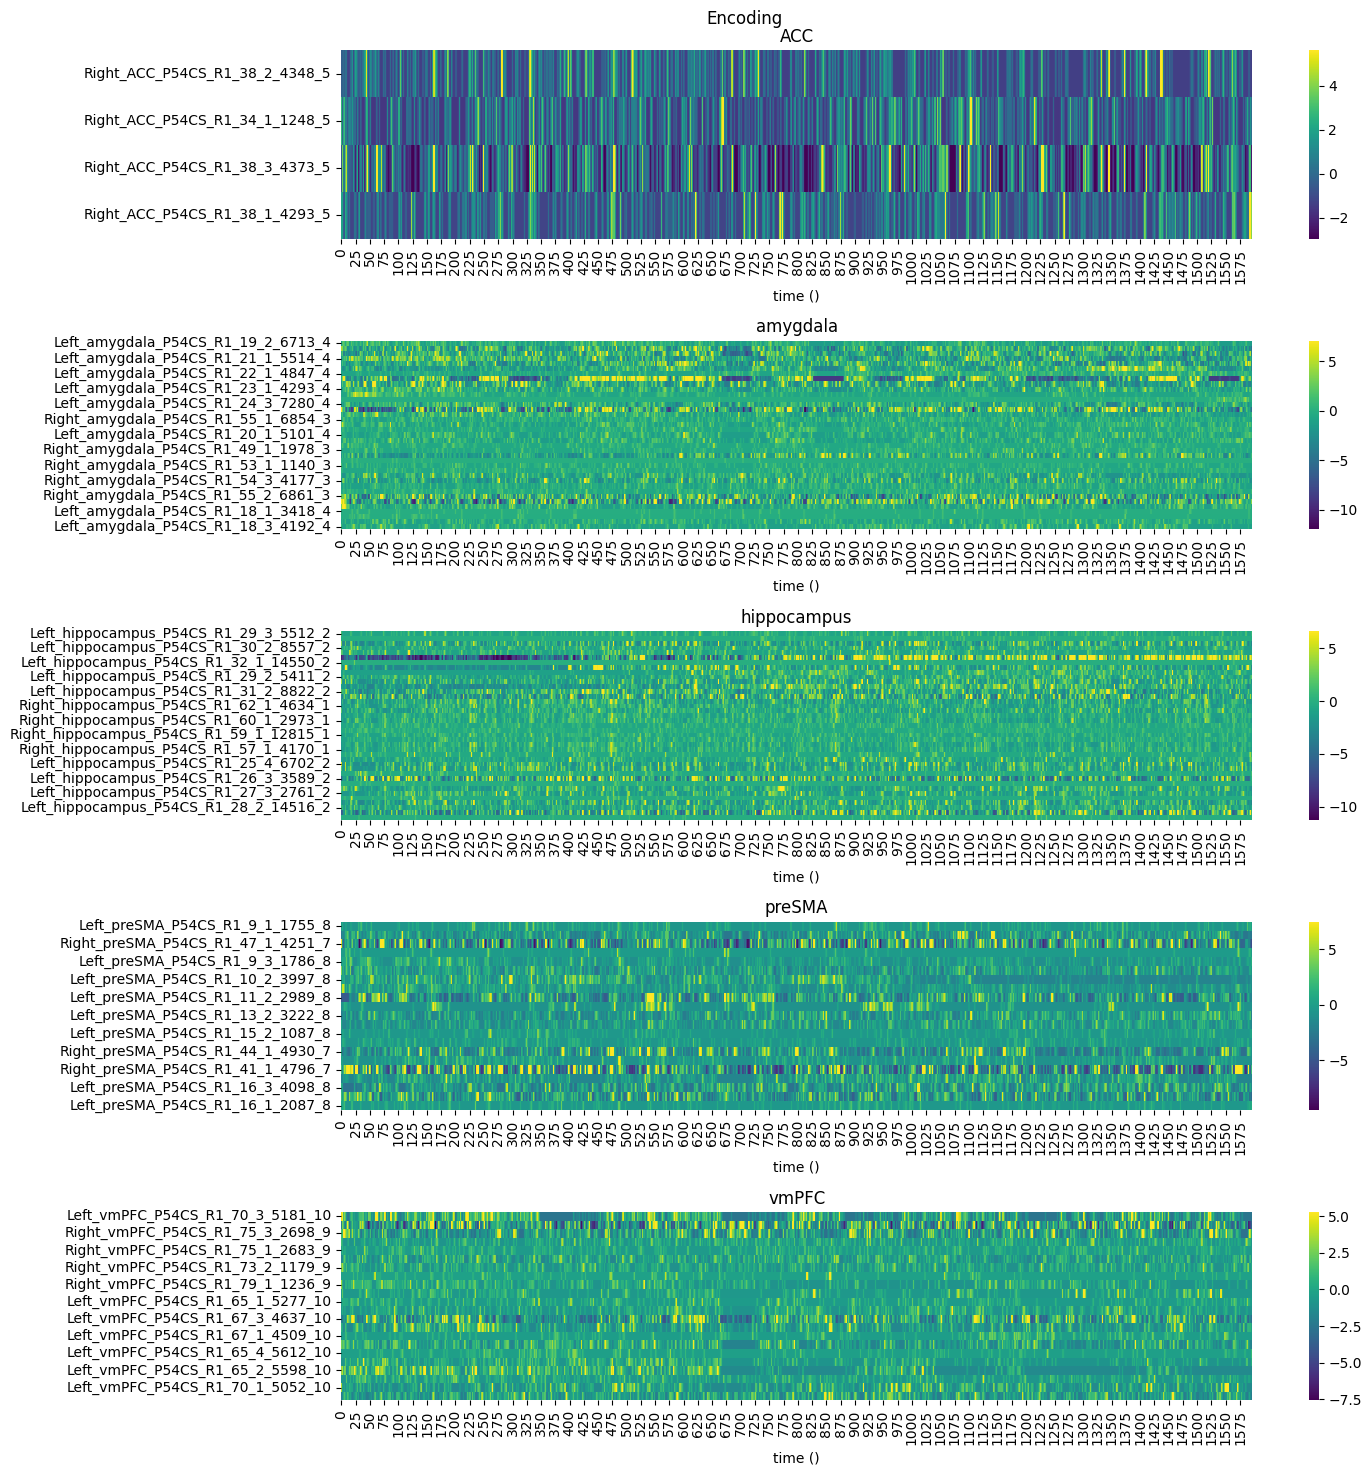

In [28]:
sess = 'P54CS_R1'
sess_cols = [col for col in rates_by_time.columns if sess in col]
sess_df = rates_by_time[sess_cols]

regions = sorted(set([col.split('_')[1] for col in sess_cols]))

print(f'plotting all {len(sess_cols)} neurons, EVEN THOSE WITH 16s PERIODS OF MISSING DATA')

fig, axs = plt.subplots(5, 1, figsize=(15, 15))
axs, ax = axs.flatten(), 0

for region in regions:

    region_cols = [col for col in sess_df.columns if region in col]
    sess_reg_df = sess_df[region_cols].T

    sns.heatmap(sess_reg_df, cmap='viridis', cbar=True, ax=axs[ax], vmax = np.percentile(sess_reg_df.values, 99))
    axs[ax].set(xlabel='time ()', title = region)
    ax += 1

plt.suptitle('Encoding')

plt.tight_layout()
plt.show()